# Topic to Voer

## 1. Square Root Transformation

It is used to convert the numercial values into square root of the number.

### Intuition

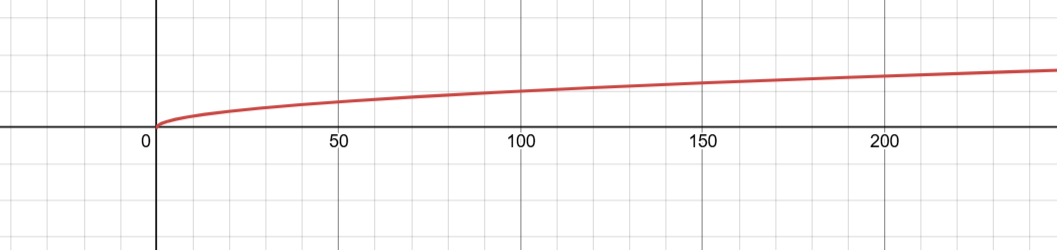

It is used to penalize the larger values , but not as aggresively as log.

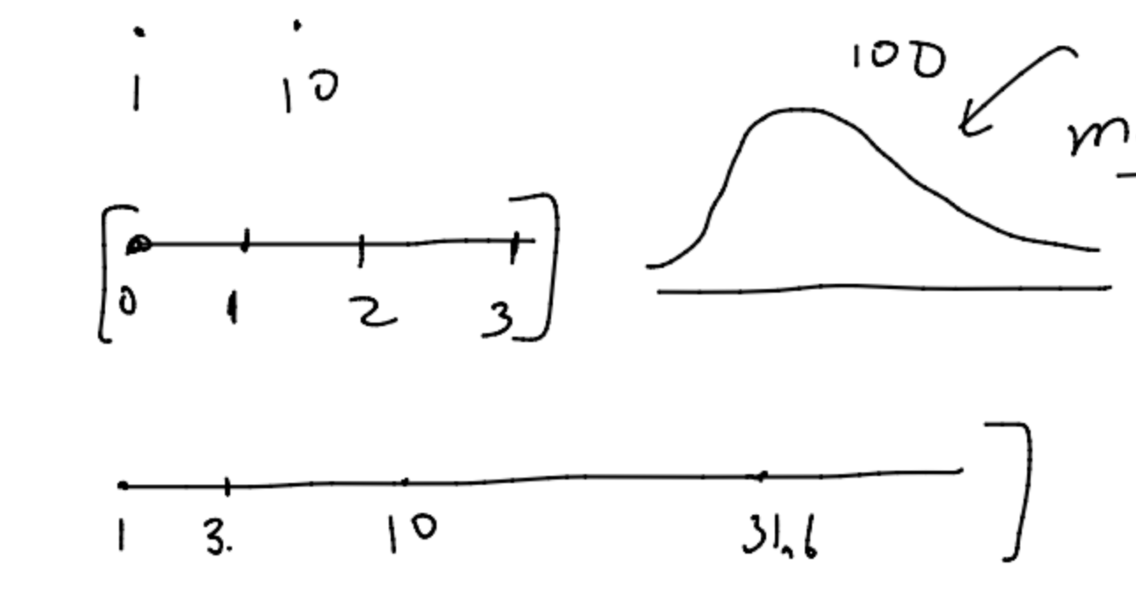

### When To Use Square Root Transformation

1. When the data is Right Skewed.

2. Skewness should be in the range of [0,1] -> Also called as mild skewness.

(These are just heuristics which people suggest)

## 2. Square Transformation

Just square up the numerical values.

### Intuition

Upward Parabola is formed.

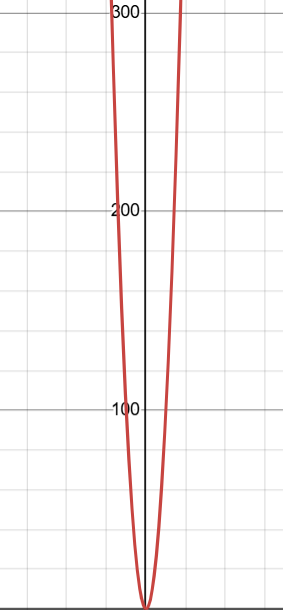

### When to use

1. use with left skewed Data.

2. Skewness should lie in the range of [-1,0] -> Also known as mild skewness.

3. It can be a useful transformation in case of non linear relationship specifically when the relationship is parabolic.

## 3. Reciprocal Transformation

Take the inverse of current value. (1/x)

### Intuition

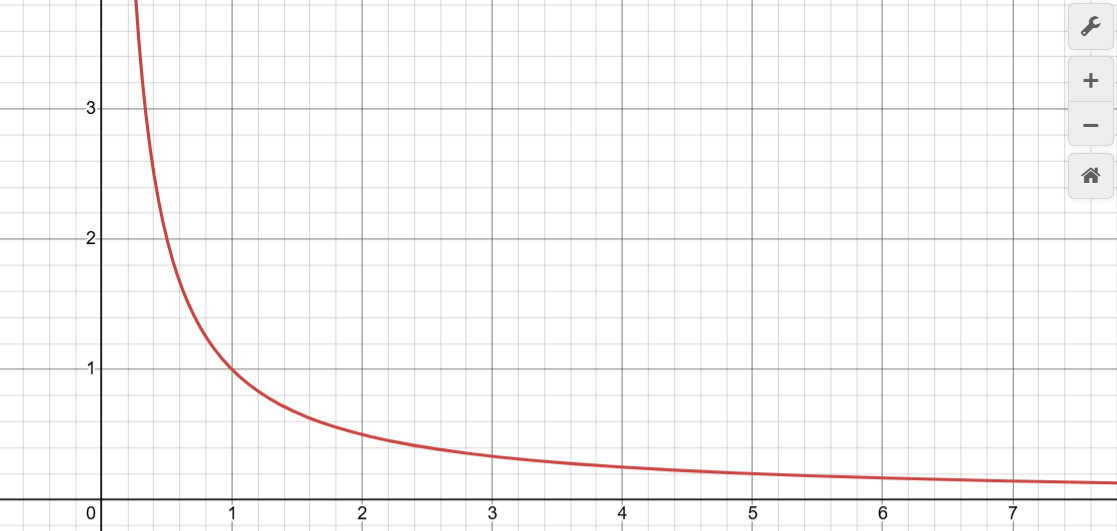

For values of x ranging from x = 0 to x = 1 , the values of y are very high which can result in outliers after transformation.

the best case scenario is when x > 1 , that will ensure y will remain in the range of [0,1].

### When to use it

1. When we have right skewed data.

2. Typically useful for high skewness which is when skewness is grater than 3 or 4.

3. To transform the inverse relation to linear relation.

In [117]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from scipy.stats import skew
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_squared_error
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

### Transforming the parabolic data into linear data using square transformation.

In [118]:
# Seed for reproducibility
np.random.seed(42)

# Generate 200 random X values between 0 and 10
X = np.random.uniform(0, 10, 200)

# Calculate Y using a quadratic relationship and add some noise
Y = -X**2 + 10*X + np.random.normal(0, 5, 200)

# Convert X and Y into a DataFrame for easier manipulation
df = pd.DataFrame({'X': X, 'Y': Y})

df.head()

,X,Y
0,3.745401,20.025858
1,9.507143,5.846930
2,7.319939,21.083243
3,5.986585,20.454893
4,1.560186,22.496555


In [119]:
df['X_squared'] = df['X']**2

df.head()

,X,Y,X_squared
0,3.745401,20.025858,14.028030
1,9.507143,5.846930,90.385769
2,7.319939,21.083243,53.581513
3,5.986585,20.454893,35.839198
4,1.560186,22.496555,2.434182


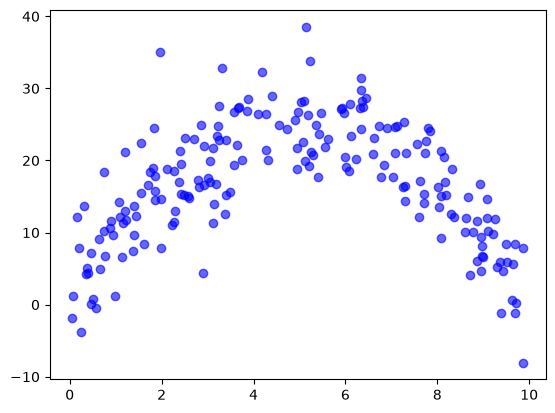

In [120]:
df_sorted = df.sort_values(by='X')

plt.scatter(df_sorted['X'], df_sorted['Y'], color='blue', label='Actual Data', alpha=0.6)

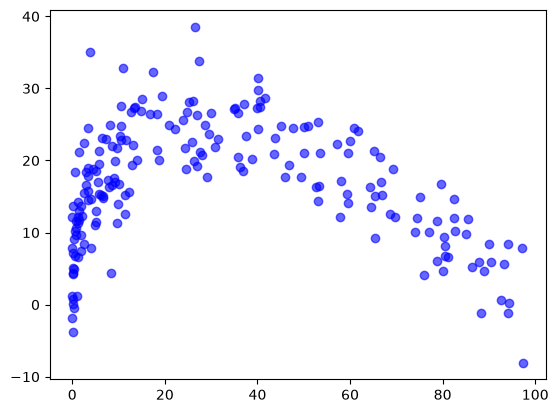

In [121]:
plt.scatter(df_sorted['X_squared'], df_sorted['Y'], color='blue', label='Actual Data', alpha=0.6)

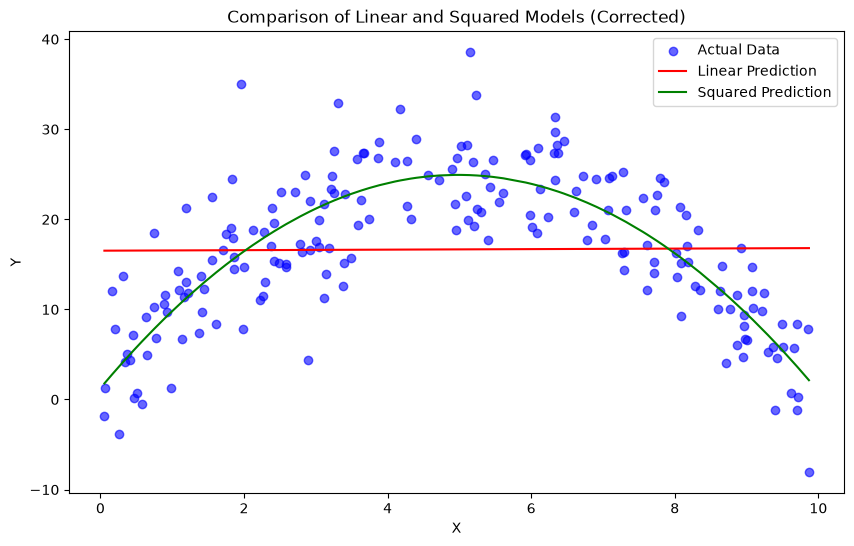

In [122]:
# Linear model using X
linear_model = LinearRegression()
linear_model.fit(df[['X']], df['Y'])
df['Linear_Prediction'] = linear_model.predict(df[['X']])

# Linear model using X^2
df['X_squared'] = df['X']**2
squared_model = LinearRegression()
squared_model.fit(df[['X', 'X_squared']], df['Y'])
df['Squared_Prediction'] = squared_model.predict(df[['X', 'X_squared']])

# Sort the dataframe by X values for better plotting
df_sorted = df.sort_values(by='X')

# Plot the data and the models with sorted values
plt.figure(figsize=(10, 6))
plt.scatter(df_sorted['X'], df_sorted['Y'], color='blue', label='Actual Data', alpha=0.6)
plt.plot(df_sorted['X'], df_sorted['Linear_Prediction'], color='red', label='Linear Prediction')
plt.plot(df_sorted['X'], df_sorted['Squared_Prediction'], color='green', label='Squared Prediction')
plt.title('Comparison of Linear and Squared Models (Corrected)')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()

In [123]:
df = pd.read_csv('https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv')

In [124]:
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [125]:
df.skew()['crim']

np.float64(5.223148798243851)

In [126]:
df['chas'].value_counts()

chas
0    471
1     35
Name: count, dtype: int64

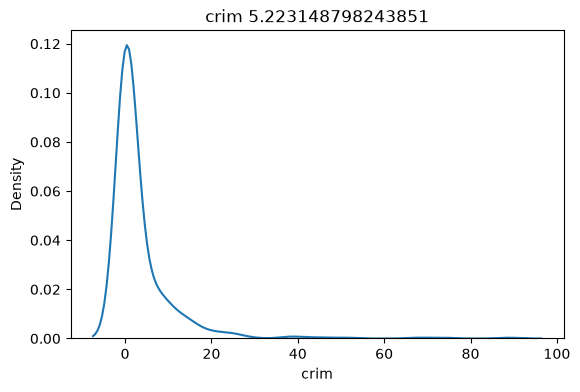

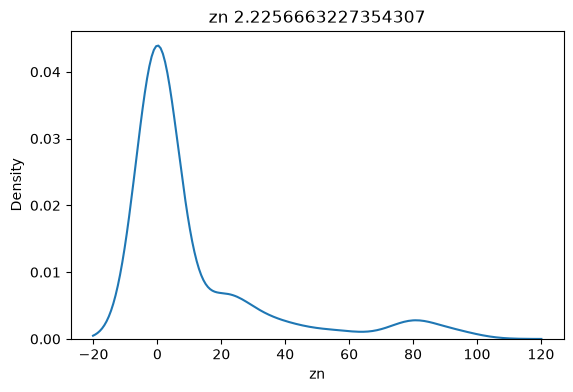

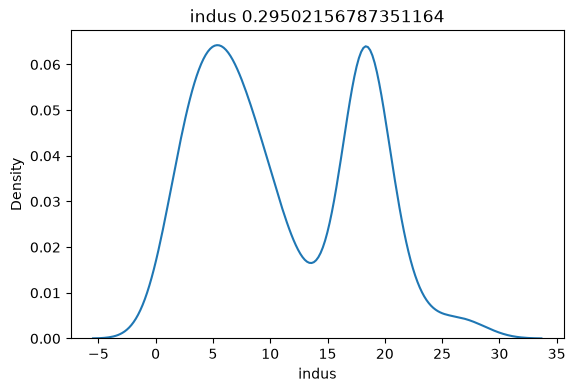

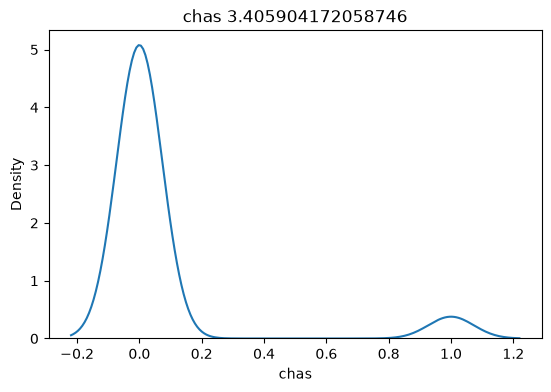

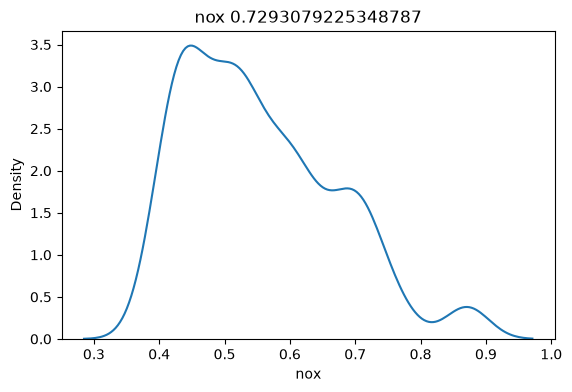

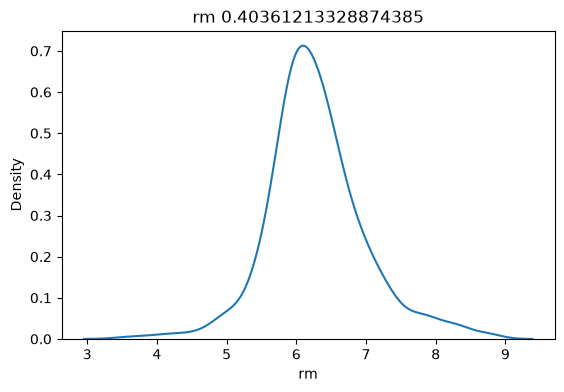

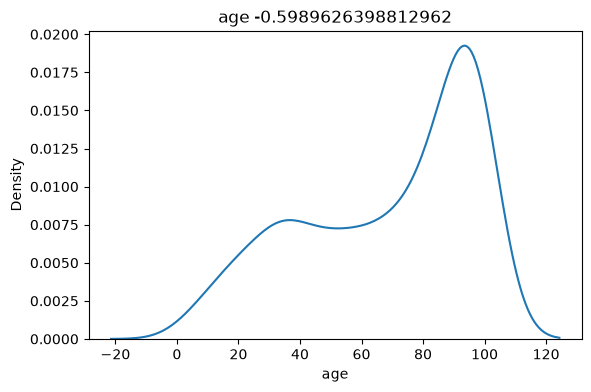

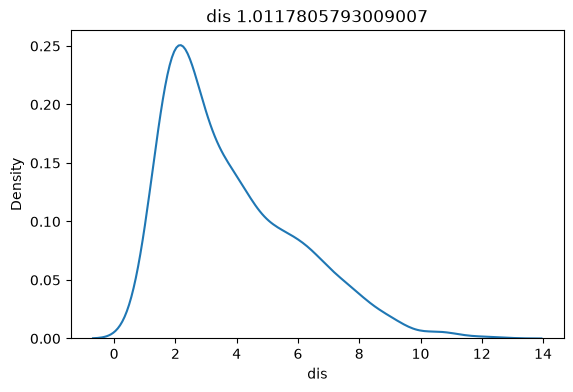

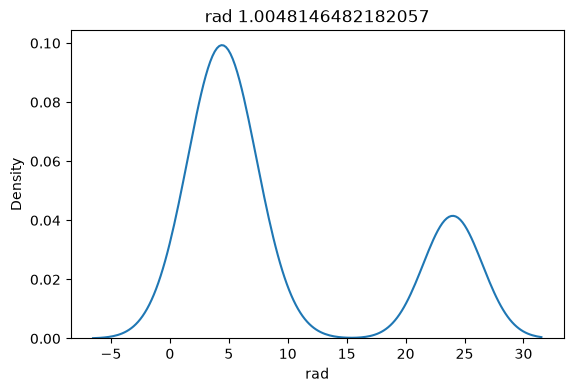

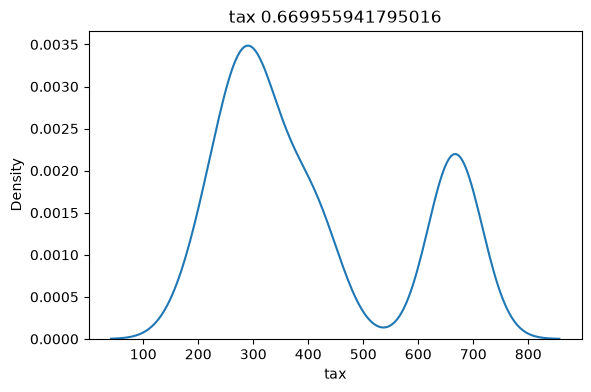

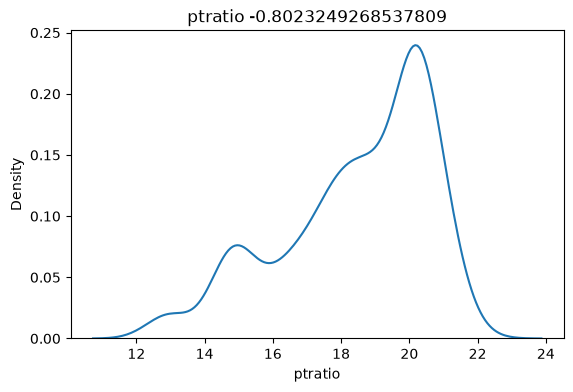

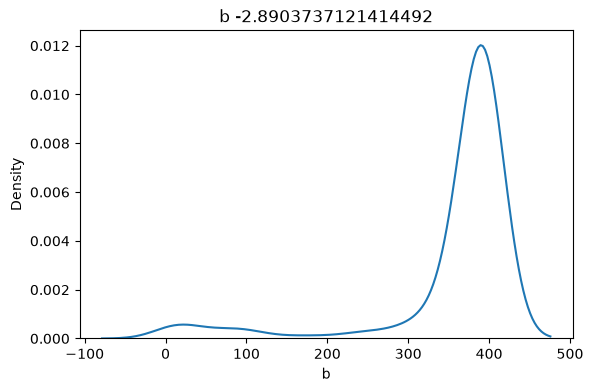

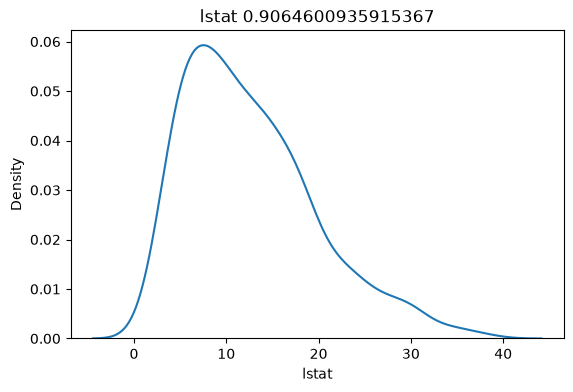

In [127]:
for col in df.columns[0:-1]:
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    sns.kdeplot(df[col])
    txt = col + " " + str(df.skew()[col])
    plt.title(txt)
    plt.show()

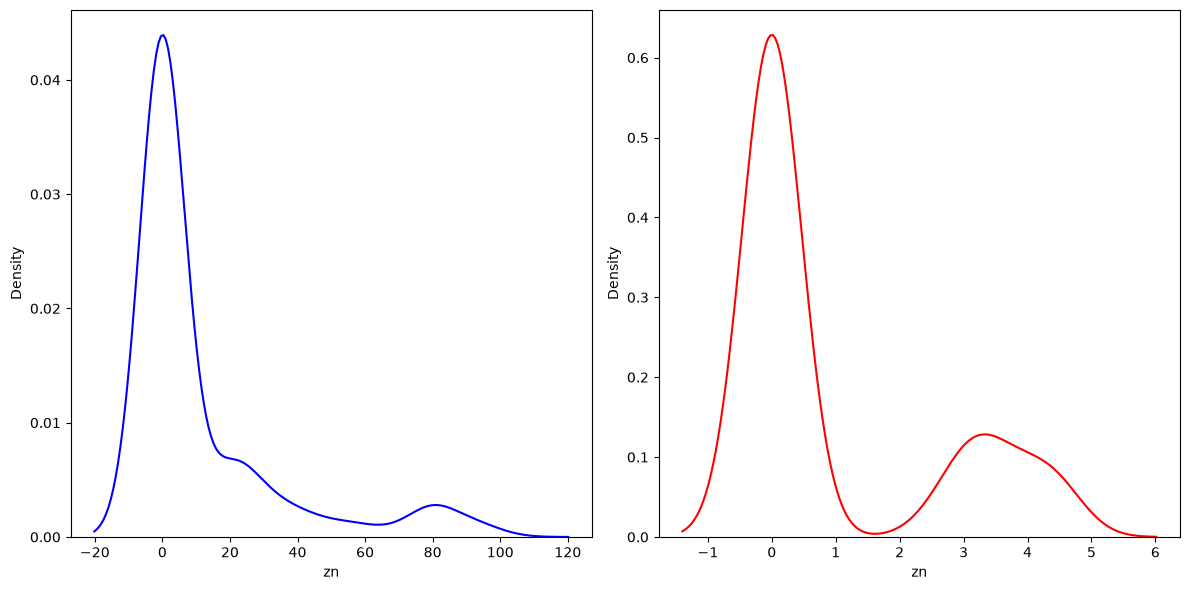

skew before log transform 2.219063057148425
skew after log transform 1.1899105701640726


In [128]:
fig, axs = plt.subplots(ncols=2, figsize=(12, 6))

# Plotting the normal distribution
sns.kdeplot(df['zn'], color='blue', ax=axs[0])

# Plotting the exponential distribution
sns.kdeplot(np.log1p(df['zn']), color='red', ax=axs[1])

plt.tight_layout()
plt.show()

print('skew before log transform', skew(df['zn']))
print('skew after log transform', skew(np.log1p(df['zn'])))

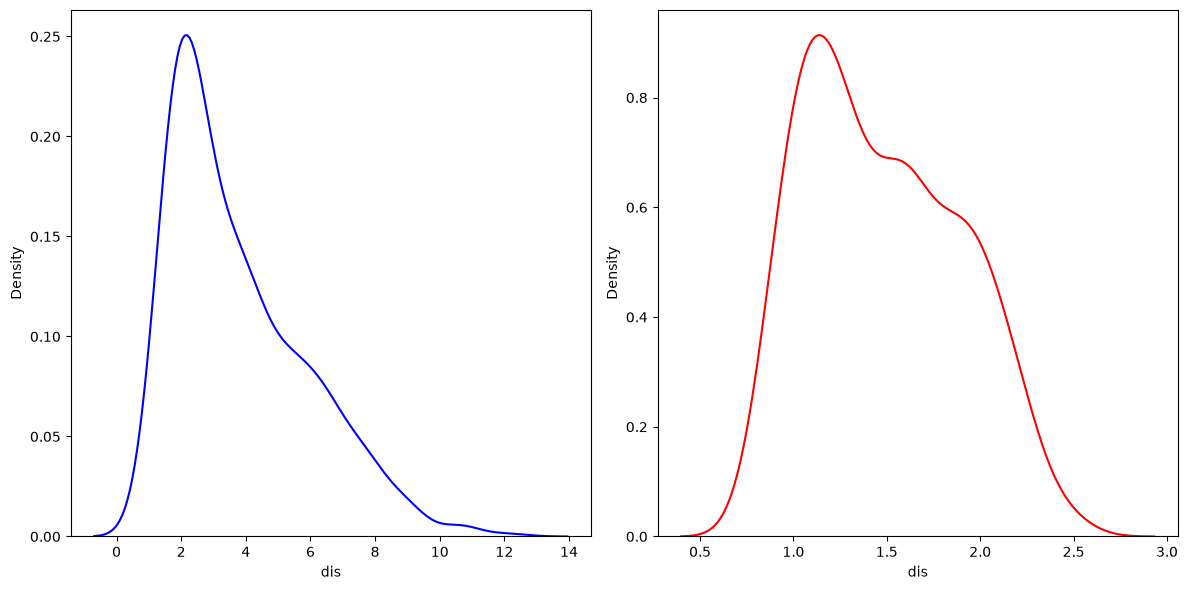

skew before log transform 1.0087787565152246
skew after log transform 0.3305777426343001


In [129]:
# log on dis

# Setting up the matplotlib figure with two subplots
fig, axs = plt.subplots(ncols=2, figsize=(12, 6))

# Plotting the normal distribution
sns.kdeplot(df['dis'], color='blue', ax=axs[0])

# Plotting the exponential distribution
sns.kdeplot(np.log1p(df['dis']), color='red', ax=axs[1])

plt.tight_layout()
plt.show()

print('skew before log transform', skew(df['dis']))
print('skew after log transform', skew(np.log1p(df['dis'])))

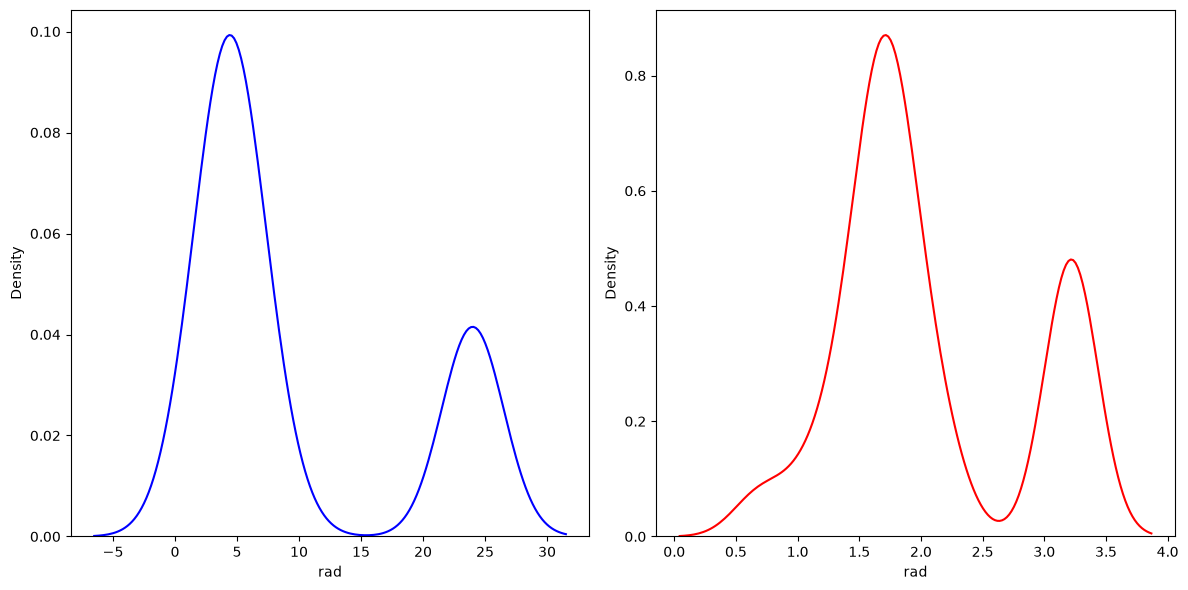

skew before log transform 1.0018334924536951
skew after log transform 0.5311793311965491


In [130]:
# log on rad

# Setting up the matplotlib figure with two subplots
fig, axs = plt.subplots(ncols=2, figsize=(12, 6))

# Plotting the normal distribution
sns.kdeplot(df['rad'], color='blue', ax=axs[0])

# Plotting the exponential distribution
sns.kdeplot(np.log1p(df['rad']), color='red', ax=axs[1])

plt.tight_layout()
plt.show()

print('skew before log transform', skew(df['rad']))
print('skew after log transform', skew(np.log1p(df['rad'])))

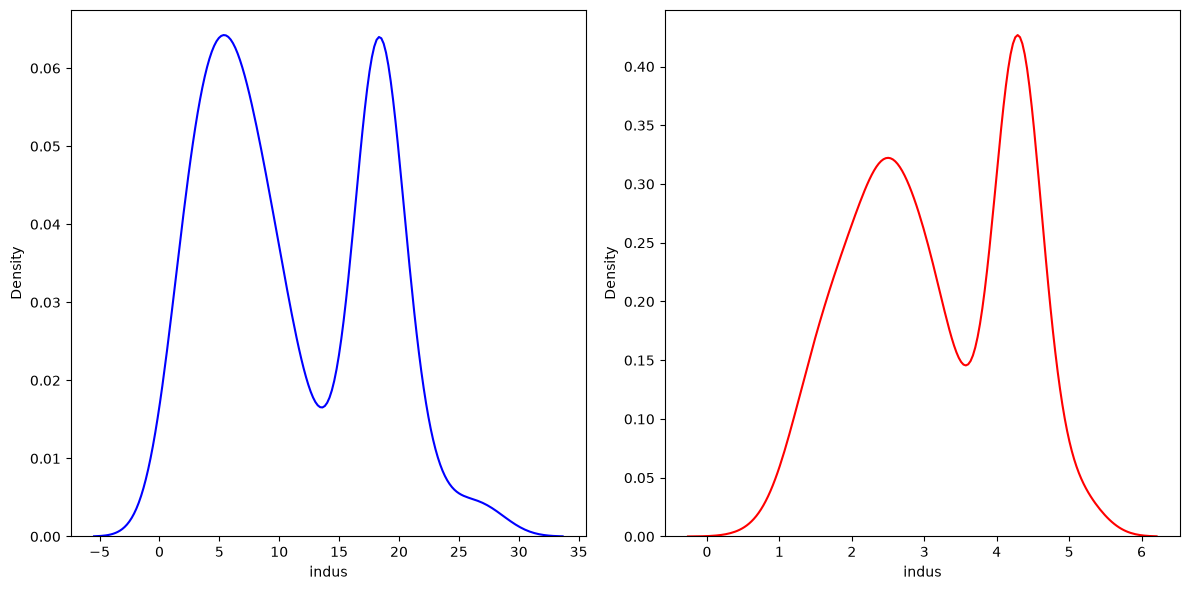

skew before sqrt transform 0.29414627684418543
skew after sqrt transform -0.07239396333108224


In [131]:
# sqrt on indus

# Setting up the matplotlib figure with two subplots
fig, axs = plt.subplots(ncols=2, figsize=(12, 6))

# Plotting the normal distribution
sns.kdeplot(df['indus'], color='blue', ax=axs[0])

# Plotting the exponential distribution
sns.kdeplot(np.sqrt(df['indus']), color='red', ax=axs[1])

plt.tight_layout()
plt.show()

print('skew before sqrt transform', skew(df['indus']))
print('skew after sqrt transform', skew(np.sqrt(df['indus'])))

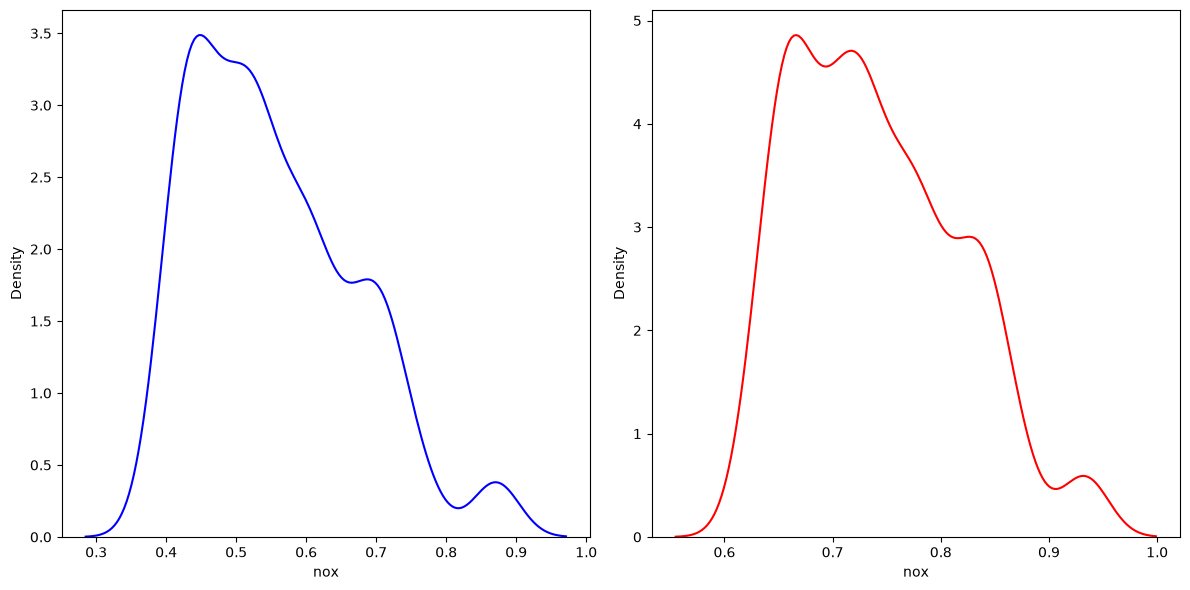

skew before sqrt transform 0.7271441597740319
skew after sqrt transform 0.5351964490014817


In [132]:
# sqrt on nox

# Setting up the matplotlib figure with two subplots
fig, axs = plt.subplots(ncols=2, figsize=(12, 6))

# Plotting the normal distribution
sns.kdeplot(df['nox'], color='blue', ax=axs[0])

# Plotting the exponential distribution
sns.kdeplot(np.sqrt(df['nox']), color='red', ax=axs[1])

plt.tight_layout()
plt.show()

print('skew before sqrt transform', skew(df['nox']))
print('skew after sqrt transform', skew(np.sqrt(df['nox'])))

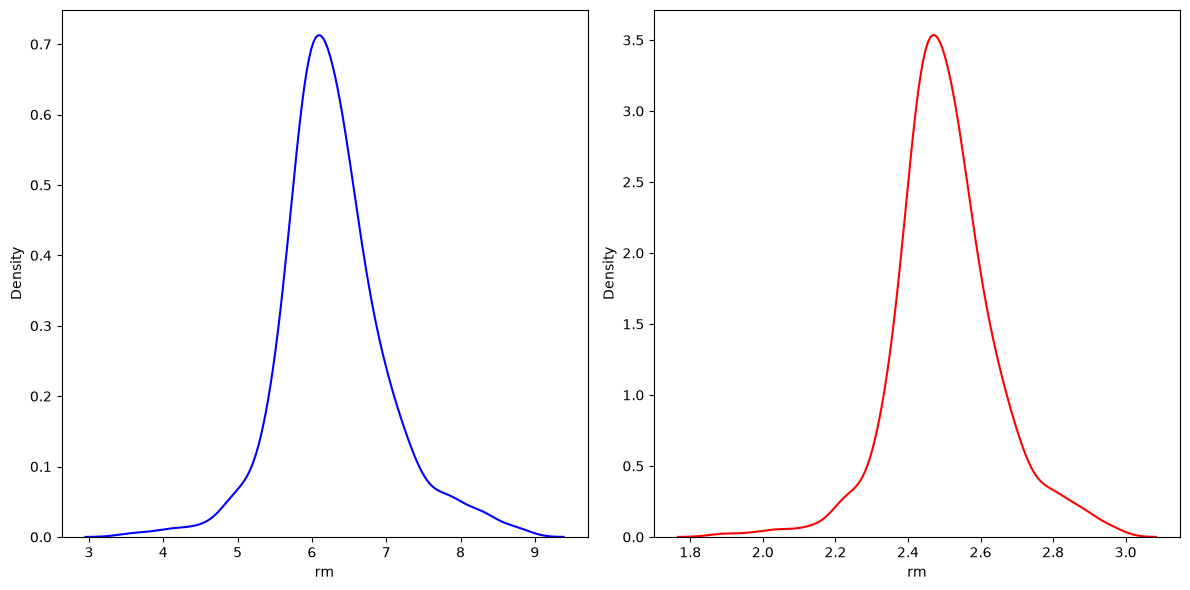

skew before sqrt transform 0.40241466802496245
skew after sqrt transform 0.07249861410468098


In [133]:
# sqrt on rm

# Setting up the matplotlib figure with two subplots
fig, axs = plt.subplots(ncols=2, figsize=(12, 6))

# Plotting the normal distribution
sns.kdeplot(df['rm'], color='blue', ax=axs[0])

# Plotting the exponential distribution
sns.kdeplot(np.sqrt(df['rm']), color='red', ax=axs[1])

plt.tight_layout()
plt.show()

print('skew before sqrt transform', skew(df['rm']))
print('skew after sqrt transform', skew(np.sqrt(df['rm'])))

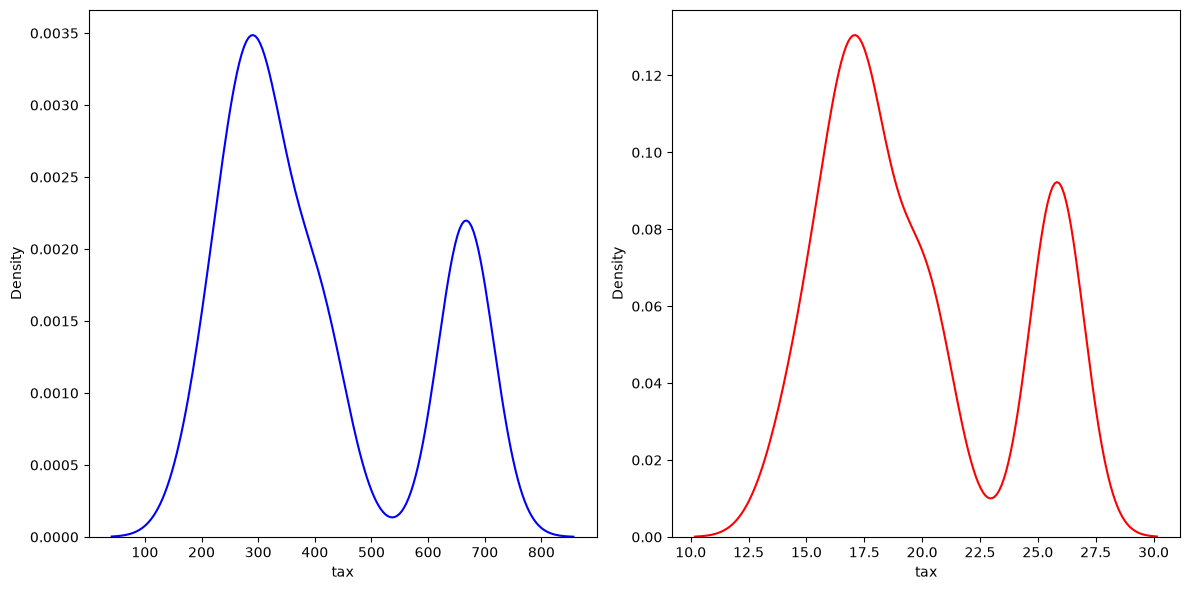

skew before sqrt transform 0.6679682687237768
skew after sqrt transform 0.5202453627239406


In [134]:
# sqrt on tax

# Setting up the matplotlib figure with two subplots
fig, axs = plt.subplots(ncols=2, figsize=(12, 6))

# Plotting the normal distribution
sns.kdeplot(df['tax'], color='blue', ax=axs[0])

# Plotting the exponential distribution
sns.kdeplot(np.sqrt(df['tax']), color='red', ax=axs[1])

plt.tight_layout()
plt.show()

print('skew before sqrt transform', skew(df['tax']))
print('skew after sqrt transform', skew(np.sqrt(df['tax'])))

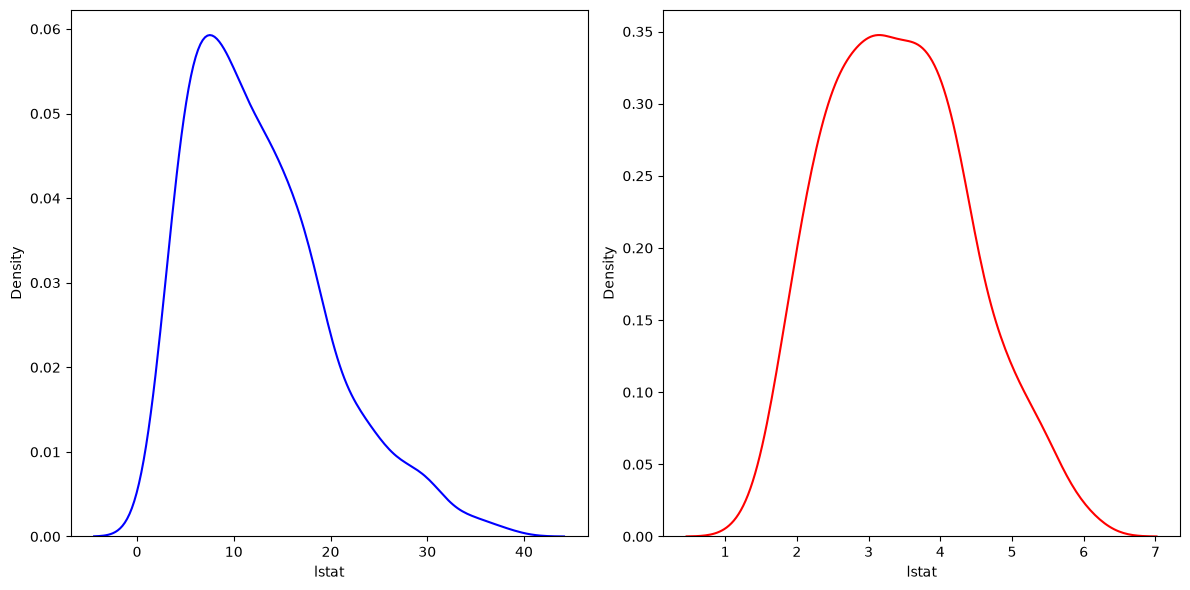

skew before sqrt transform 0.9037707431346133
skew after sqrt transform 0.30647851994358943


In [135]:
# sqrt on lstat

# Setting up the matplotlib figure with two subplots
fig, axs = plt.subplots(ncols=2, figsize=(12, 6))

# Plotting the normal distribution
sns.kdeplot(df['lstat'], color='blue', ax=axs[0])

# Plotting the exponential distribution
sns.kdeplot(np.sqrt(df['lstat']), color='red', ax=axs[1])

plt.tight_layout()
plt.show()

print('skew before sqrt transform', skew(df['lstat']))
print('skew after sqrt transform', skew(np.sqrt(df['lstat'])))

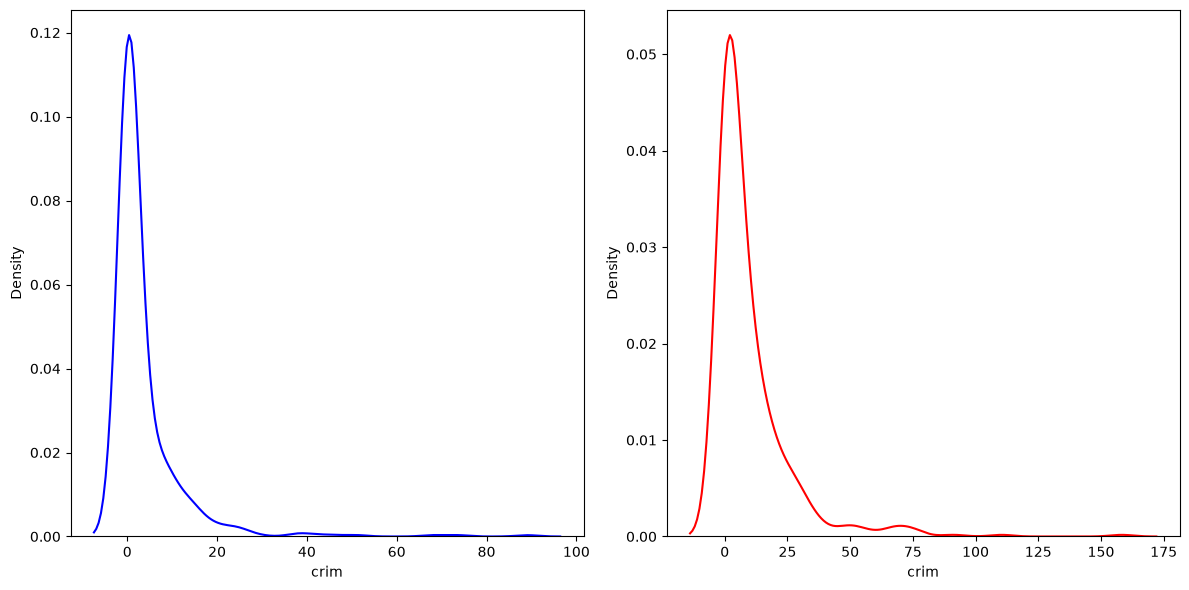

skew before reciprocal transform 5.207652387859715
skew after reciprocal transform 3.733474573321791


In [136]:
# reciprocal on crim

# Setting up the matplotlib figure with two subplots
fig, axs = plt.subplots(ncols=2, figsize=(12, 6))

# Plotting the normal distribution
sns.kdeplot(df['crim'], color='blue', ax=axs[0])

# Plotting the exponential distribution
sns.kdeplot(np.reciprocal(df['crim']), color='red', ax=axs[1])

plt.tight_layout()
plt.show()

print('skew before reciprocal transform', skew(df['crim']))
print('skew after reciprocal transform', skew(np.reciprocal(df['crim'])))

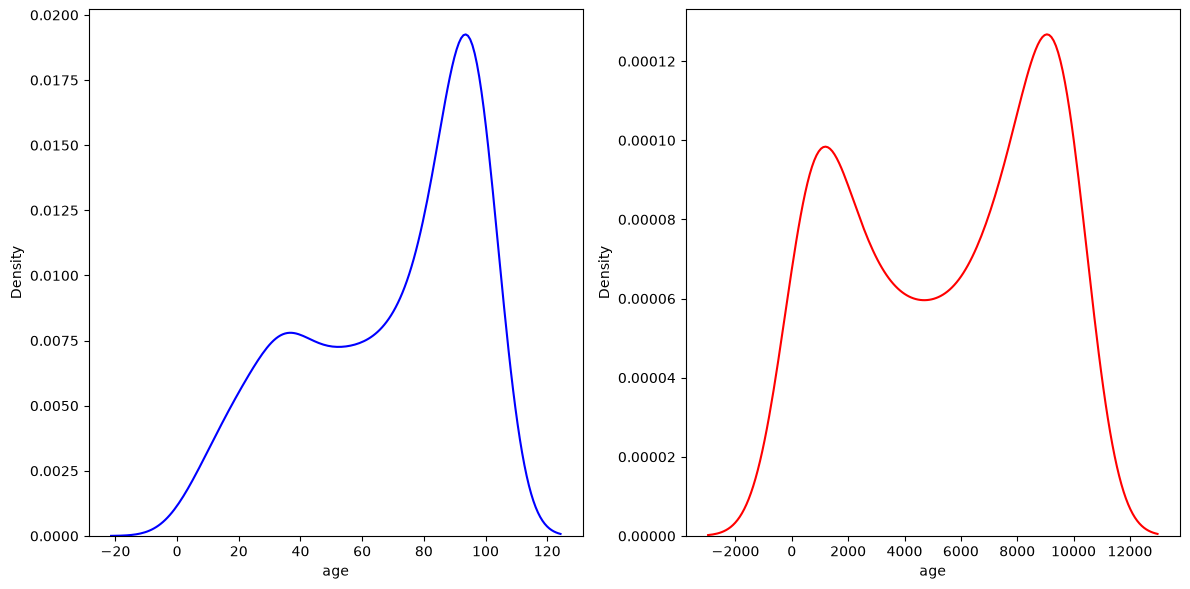

skew before reciprocal transform -0.5971855948016143
skew after reciprocal transform -0.18263633415807376


In [137]:
# square on age

# Setting up the matplotlib figure with two subplots
fig, axs = plt.subplots(ncols=2, figsize=(12, 6))

# Plotting the normal distribution
sns.kdeplot(df['age'], color='blue', ax=axs[0])

# Plotting the exponential distribution
sns.kdeplot(np.square(df['age']), color='red', ax=axs[1])

plt.tight_layout()
plt.show()

print('skew before reciprocal transform', skew(df['age']))
print('skew after reciprocal transform', skew(np.square(df['age'])))

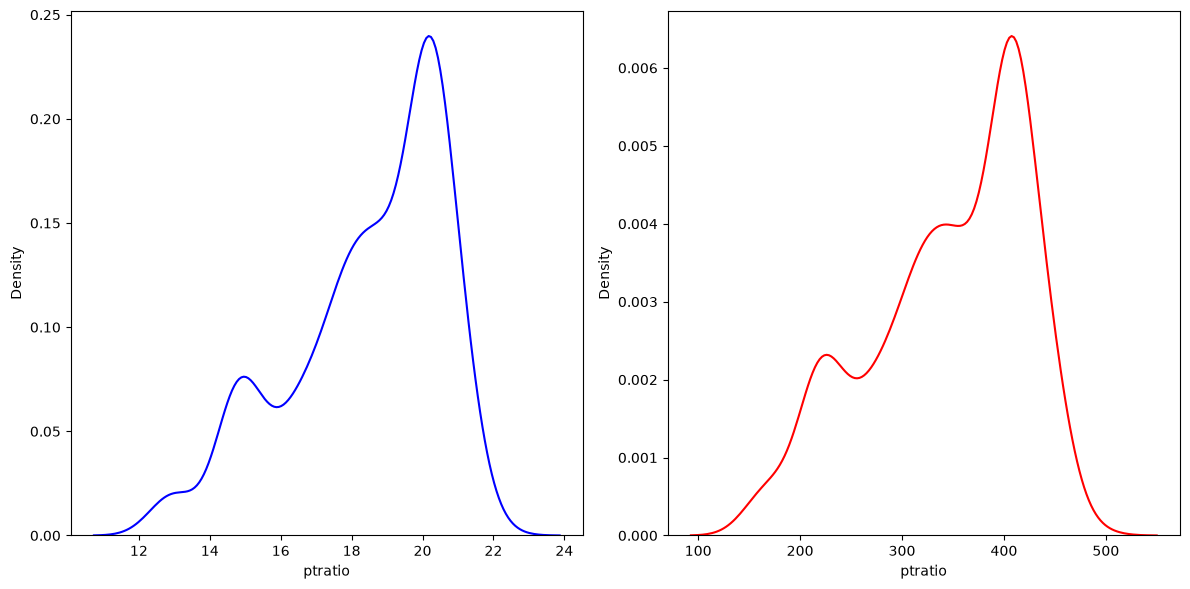

skew before reciprocal transform -0.7999445320367449
skew after reciprocal transform -0.6085086626298968


In [138]:
# square on ptratio

# Setting up the matplotlib figure with two subplots
fig, axs = plt.subplots(ncols=2, figsize=(12, 6))

# Plotting the normal distribution
sns.kdeplot(df['ptratio'], color='blue', ax=axs[0])

# Plotting the exponential distribution
sns.kdeplot(np.square(df['ptratio']), color='red', ax=axs[1])

plt.tight_layout()
plt.show()

print('skew before reciprocal transform', skew(df['ptratio']))
print('skew after reciprocal transform', skew(np.square(df['ptratio'])))

In [139]:
-df['b']

0     -396.90
1     -396.90
2     -392.83
3     -394.63
4     -396.90
        ...  
501   -391.99
502   -396.90
503   -396.90
504   -393.45
505   -396.90
Name: b, Length: 506, dtype: float64

## Transforming after Mirroring for heavy left skewed data

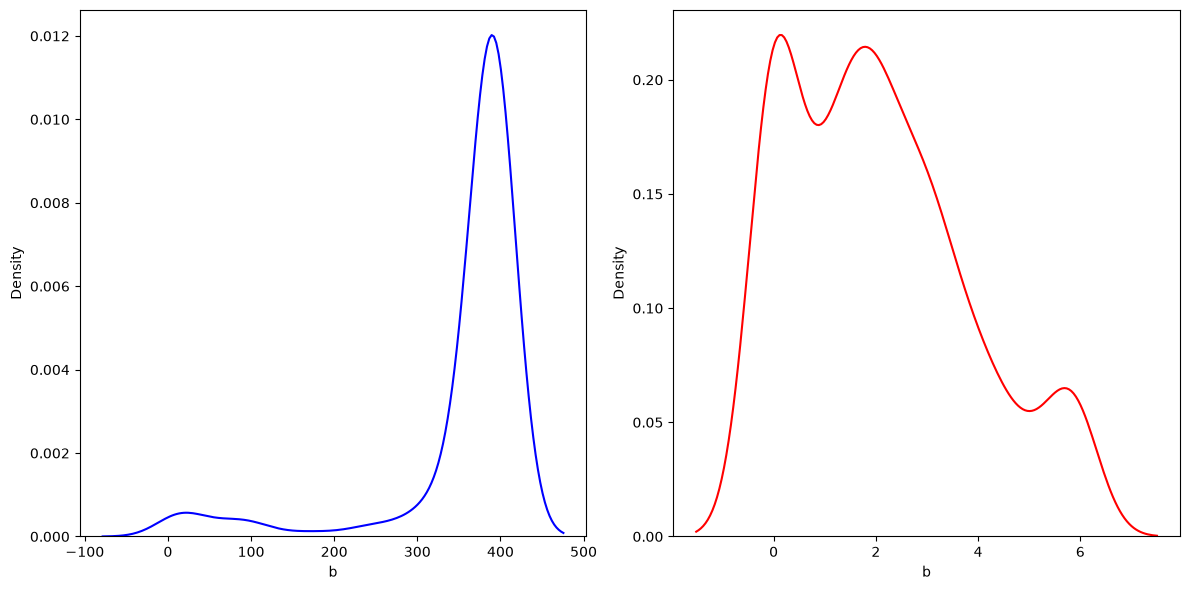

skew before reflect log transform -2.8817983452627716
skew after reflect log transform 0.5995750622214899


In [140]:
# reflect log on b

# Setting up the matplotlib figure with two subplots
fig, axs = plt.subplots(ncols=2, figsize=(12, 6))

# Plotting the normal distribution
sns.kdeplot(df['b'], color='blue', ax=axs[0])

# Plotting the exponential distribution
sns.kdeplot(np.log1p(-df['b'] + 396.900000001), color='red', ax=axs[1])

plt.tight_layout()
plt.show()

from scipy.stats import skew

print('skew before reflect log transform', skew(df['b']))
print('skew after reflect log transform', skew(np.log1p(-df['b'] + 396.900000001)))

In [141]:
# log -> zn, chas, dis, rad
# sqrt -> indus, nox, rm, tax, lstat
# reciprocal -> crim
# square -> age, ptratio
# reflect shift log -> b

In [142]:
# baseline model

from sklearn.model_selection import train_test_split

# Define your features and target variable
X = df.drop('medv', axis=1)  # Features
y = df['medv']  # Target variable

# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [143]:
from sklearn.linear_model import LinearRegression

reg = LinearRegression()

reg.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [144]:
y_pred = reg.predict(X_test)

print('r2 score', r2_score(y_test, y_pred))
print('mse', mean_squared_error(y_test, y_pred))

r2 score 0.6687594935356317
mse 24.291119474973538


In [145]:
def reflect_shift_log_transform(x):

    return np.log1p(-x + 396.900000001)

In [146]:
preprocessor = ColumnTransformer(
    transformers=[
        ('log', FunctionTransformer(np.log1p), ['zn', 'chas', 'dis', 'rad']),
        ('sqrt', FunctionTransformer(np.sqrt), ['indus', 'nox', 'rm', 'tax', 'lstat']),
        ('reciprocal', FunctionTransformer(np.reciprocal), ['crim']),
        ('square', FunctionTransformer(np.square), ['age', 'ptratio']),
        ('reflect_shift_log', FunctionTransformer(reflect_shift_log_transform), ['b']),
    ],
    remainder='passthrough'  # Keeps columns not listed unchanged
)

In [147]:
X_train_trf = preprocessor.fit_transform(X_train)

In [148]:
X_test_trf = preprocessor.transform(X_test)

In [149]:
reg = LinearRegression()

reg.fit(X_train_trf, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [150]:
y_pred = reg.predict(X_test_trf)

print('r2 score', r2_score(y_test, y_pred))
print('mse', mean_squared_error(y_test, y_pred))

r2 score 0.7219859878030963
mse 20.387819285979116
